# SecondHalf

**An AI-powered offline-life companion for retired adults.**
*Spend less time scrolling. Spend more time living.*

SecondHalf suggests **one** meaningful offline activity that suits the person, their free time, their energy and their mood, and then asks them to put the phone away.

This single notebook contains the whole project. It demonstrates four ideas working together:

| Idea | Where in this notebook |
|---|---|
| **Retrieval-Augmented Generation (RAG)** | Sections 3, 4, 6 |
| **Teacher-student knowledge distillation** | Section 5 |
| **Structured LLM output** (Pydantic) and a **grounding check** | Section 6 |
| **LLM tracing** (LangSmith, optional) | Section 12 |

## The pipeline

```
 profile + today's request
          |
          v
 Student classifier (TF-IDF + Logistic Regression, local)  -->  category, intent
          |
          v
 Build search sentence + metadata filter  <--  history and feedback (titles to avoid)
          |
          v
 Chroma vector store (200 activities, MiniLM embeddings)   -->  top-5 activities + similarity
          |
          v
 Prompt: "the retrieved activities are the source of truth" -->  Groq LLM
          |
          v
 Pydantic validation  -->  grounding check  -->  ONE recommendation
          |
          v
 "I'll do this"  -->  phone away  -->  feedback  -->  stored in history
```

## How to run

1. Open this notebook in Jupyter or VS Code and select the project's `.venv` as the kernel.
2. Put `GROQ_API_KEY=...` in the `.env` file next to this notebook (free key: https://console.groq.com/keys).
3. **Run All.** The first run downloads the embedding model (about 90 MB) once.

Without a key, everything except the final LLM step still runs: the dataset, embeddings, retrieval, the student model, its evaluation and the sanity checks. Cells that need the LLM say so and skip.

## 1. Setup

All settings live in this one cell. The data files are read from the `data/` folder next to the notebook.

In [1]:
# First time only: install the packages into this environment, then restart the kernel.
# %pip install -q -r requirements.txt ipykernel ipywidgets matplotlib

import csv
import html
import json
import os
import re
import time
from dataclasses import asdict, dataclass, field
from datetime import date, timedelta
from difflib import SequenceMatcher

import matplotlib.pyplot as plt
import pandas as pd
from dotenv import load_dotenv
from IPython.display import HTML, display
from langsmith import traceable

load_dotenv(".env")
pd.set_option("display.max_colwidth", None)

# --- files ---
ACTIVITIES_CSV = "data/activities.csv"                          # 200 hand-designed activities
TEACHER_DATA_JSONL = "data/teacher_training_data.jsonl"         # 392 teacher-labelled queries
EVALUATION_QUESTIONS_JSON = "data/evaluation_questions.json"    # 8 evaluation questions
USER_DATA_PATH = "data/user_data_notebook.json"                 # profile + history (created by the app in section 11)

# --- retrieval ---
EMBEDDING_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
RETRIEVAL_K = 5
# Similarity bonus for activities in the student-predicted category when the
# user didn't pick a category themselves (a soft prior, not a filter).
CATEGORY_BOOST = 0.05

# --- LLM ---
GROQ_API_KEY = (os.getenv("GROQ_API_KEY") or "").strip() or None
GROQ_MODEL = os.getenv("GROQ_MODEL", "openai/gpt-oss-20b")
HAS_KEY = GROQ_API_KEY is not None
NO_KEY_MESSAGE = "No GROQ_API_KEY in .env - this cell needs the LLM, so it was skipped."

CATEGORIES = [
    "learn", "create", "connect", "contribute", "physical_outdoor",
    "hobbies", "family", "memory", "practical_useful", "mindfulness_reflection",
]


def require_groq_key() -> str:
    """Raise a clear error only when a step that actually needs Groq runs without a key."""
    if not GROQ_API_KEY:
        raise RuntimeError(
            "GROQ_API_KEY is not set. Add your key from https://console.groq.com/keys to the .env file."
        )
    return GROQ_API_KEY


def get_llm(temperature: float = 0.0):
    """One place that creates the Groq chat model, so the model is swappable via GROQ_MODEL."""
    from langchain_groq import ChatGroq
    return ChatGroq(model=GROQ_MODEL, api_key=require_groq_key(), temperature=temperature, timeout=30, max_retries=2)


print("Groq key found:", "yes" if HAS_KEY else "no")
print("LLM model:", GROQ_MODEL)
print("LangSmith tracing:", "on" if os.getenv("LANGCHAIN_TRACING_V2", "false").lower() == "true" else "off")

Groq key found: yes
LLM model: openai/gpt-oss-20b
LangSmith tracing: on


## 2. The dataset

`data/activities.csv` holds **200 hand-designed activities**, 20 in each of 10 categories, written for retired adults in India (teaching grandchildren, temple walks, tutoring, composting, organising family photos, and so on). Most need no smartphone.

This dataset is the **source of truth** for the whole system: the LLM is only ever allowed to recommend something that exists here.

List fields (`interests`, `purpose`, `instructions`, `tags`) are stored in the CSV as JSON strings, so the loader parses them back into Python lists.

In [2]:
LIST_FIELDS = ("interests", "purpose", "instructions", "tags")


def load_activities(csv_path: str = ACTIVITIES_CSV) -> list[dict]:
    """Read activities.csv into dicts, with list fields parsed and duration as int."""
    with open(csv_path, encoding="utf-8") as f:
        rows = list(csv.DictReader(f))
    if not rows:
        raise ValueError(f"No activities found in {csv_path}")
    for row in rows:
        for name in LIST_FIELDS:
            row[name] = json.loads(row[name])
        row["duration_minutes"] = int(row["duration_minutes"])
    return rows


activities = load_activities()
activities_df = pd.DataFrame(activities)
print(f"{len(activities_df)} activities in {activities_df['category'].nunique()} categories")
activities_df[["id", "title", "category", "duration_minutes", "energy_level", "location", "interests"]].head()

200 activities in 10 categories


,id,title,category,duration_minutes,energy_level,location,interests
0,ACT001,Learn ten words of a new language,learn,20,low,home,"[languages, reading]"
1,ACT002,Learn a magic trick,learn,30,low,home,"[magic, performance, family]"
2,ACT003,Identify local birds,learn,30,low,home,"[nature, birdwatching]"
3,ACT004,Learn three constellations,learn,30,low,outdoor,"[astronomy, science]"
4,ACT005,Learn a Sanskrit shloka,learn,25,low,home,"[spirituality, sanskrit, reading]"


In [3]:
# Activities and duration range per category
activities_df.groupby("category")["duration_minutes"].agg(activities="count", shortest="min", median="median", longest="max")

,activities,shortest,median,longest
category,,,,
connect,20,30,45.0,90
contribute,20,20,45.0,90
create,20,20,40.0,60
family,20,20,52.5,90
hobbies,20,20,30.0,90
learn,20,20,30.0,60
memory,20,25,40.0,90
mindfulness_reflection,20,10,20.0,60
physical_outdoor,20,15,30.0,90


## 3. Embeddings and the vector store

An **embedding** is a list of numbers (384 here) that represents the *meaning* of a text. Texts with similar meanings get vectors that point in similar directions, so "something with my grandson" can match "storytelling with grandchildren" even though they share few words.

- The embedding model is `all-MiniLM-L6-v2`. It runs **locally**: free, no API key, same result every time.
- Each activity becomes one `Document`: `page_content` is a descriptive paragraph (used for meaning), and `metadata` holds the structured fields (used for filtering).
- **Chroma** stores the vectors and metadata, finds the nearest vectors quickly, and can apply metadata filters in the same query. It is kept in memory here and rebuilt each time this cell runs.

In [4]:
from langchain_chroma import Chroma
from langchain_core.documents import Document
from langchain_huggingface import HuggingFaceEmbeddings
from transformers.utils import logging as hf_logging

hf_logging.disable_progress_bar()  # keep the model-loading progress bar out of the output

# normalize_embeddings=True gives every vector length 1, so cosine similarity
# ranks documents purely by direction (meaning), not by magnitude.
embeddings = HuggingFaceEmbeddings(model_name=EMBEDDING_MODEL_NAME, encode_kwargs={"normalize_embeddings": True})


def build_document(activity: dict) -> Document:
    """Turn one activity into a Document: a natural-language paragraph plus filterable metadata."""
    interests = ", ".join(activity["interests"])
    purpose = ", ".join(activity["purpose"])
    page_content = (
        f"{activity['title']}. {activity['description']} "
        f"This is a {activity['duration_minutes']}-minute {activity['location']} "
        f"activity with {activity['energy_level']} energy, suitable for a "
        f"{activity['skill_level']} skill level. "
        f"It is good for someone interested in {interests}. "
        f"Purpose: {purpose}. "
        f"Category: {activity['category']} ({activity['subcategory']}). "
        f"Materials needed: {activity['required_materials']}. "
        f"Steps: {' '.join(activity['instructions'])} "
        f"Tags: {', '.join(activity['tags'])}."
    )
    metadata = {
        "id": activity["id"],
        "title": activity["title"],
        "category": activity["category"],
        "subcategory": activity["subcategory"],
        "duration_minutes": activity["duration_minutes"],
        "energy_level": activity["energy_level"],
        "location": activity["location"],
        "skill_level": activity["skill_level"],
        "interests": interests,
        "purpose": purpose,
        "required_materials": activity["required_materials"],
        "safety_notes": activity["safety_notes"],
    }
    return Document(page_content=page_content, metadata=metadata)


documents = [build_document(a) for a in activities]

vectorstore = Chroma(
    collection_name="activities",
    embedding_function=embeddings,
    collection_metadata={"hnsw:space": "cosine"},
)
vectorstore.reset_collection()  # so re-running this cell never duplicates rows
vectorstore.add_documents(documents=documents, ids=[a["id"] for a in activities])

print(f"Embedded {vectorstore._collection.count()} activities into Chroma")
print(f"Each vector has {len(embeddings.embed_query('hello'))} dimensions\n")
print("Example document text:\n", documents[0].page_content)

Embedded 200 activities into Chroma
Each vector has 384 dimensions

Example document text:
 Learn ten words of a new language. Pick a language you've always wanted to try and learn ten new words from a phrasebook or dictionary. This is a 20-minute home activity with low energy, suitable for a easy skill level. It is good for someone interested in languages, reading. Purpose: learning, mastery. Category: learn (language). Materials needed: phrasebook or dictionary, notebook. Steps: Choose a language Pick ten everyday words Write each word with its meaning Practice saying them aloud three times Use one word in a sentence today Tags: language, vocabulary, self-study.


## 4. Retrieval

The retriever turns the user's situation into a search and returns the 5 most similar activities.

- **Query sentence:** only the *soft, semantic* parts go into the sentence (interests, how social they feel, their own words), because the embedding model compares meanings.
- **Metadata filter:** *hard* constraints are applied as a Chroma filter instead: the category, and a duration window of plus or minus 20 minutes.
- **Repetition avoidance:** titles the user did recently or disliked are removed from the results.
- **Fallbacks:** if the strict filter finds nothing, it is relaxed step by step, so a request never comes back empty just because the duration didn't line up.
- **Hard vs soft category:** if the user *chose* a category, only that category is searched. If the category is only the student model's *guess*, it becomes a small ranking boost (+0.05), so a strong match from another category can still win.

In [5]:
@dataclass
class RetrievalContext:
    """Everything needed to build a retrieval query."""
    category: str | None = None
    duration_minutes: int | None = None
    energy_level: str | None = None
    social_preference: str | None = None
    interests: list[str] = field(default_factory=list)
    avoid_titles: list[str] = field(default_factory=list)
    free_text: str = ""
    # True: the user picked the category, so only that category is searched.
    # False: it's the student's guess, so it only boosts the ranking.
    category_is_hard: bool = True


def build_query(ctx: RetrievalContext) -> str:
    """Turn the context into one natural-language sentence (semantic parts only)."""
    parts = []
    if ctx.interests:
        parts.append(f"enjoys {', '.join(ctx.interests)}")
    if ctx.social_preference:
        parts.append(f"wants {ctx.social_preference} social interaction")
    if ctx.free_text:
        parts.append(ctx.free_text)
    if not parts:
        return "a meaningful offline activity for a retired adult"
    return "An activity for a retired adult who " + " and ".join(parts) + "."


def build_metadata_filter(ctx: RetrievalContext, include_category: bool = True) -> dict | None:
    """Chroma `where` filter for the hard constraints: exact category and a duration window."""
    clauses = []
    if ctx.category and include_category:
        clauses.append({"category": {"$eq": ctx.category}})
    if ctx.duration_minutes:
        clauses.append({"duration_minutes": {"$gte": max(5, ctx.duration_minutes - 20)}})
        clauses.append({"duration_minutes": {"$lte": ctx.duration_minutes + 20}})
    if not clauses:
        return None
    return clauses[0] if len(clauses) == 1 else {"$and": clauses}


@traceable(name="rag_retrieval", run_type="retriever")
def retrieve(ctx: RetrievalContext, k: int = RETRIEVAL_K) -> tuple[str, list[tuple[Document, float]]]:
    """Return (query, [(document, similarity), ...]), best first."""
    query = build_query(ctx)
    avoid = {t.lower() for t in ctx.avoid_titles}

    def search(where: dict | None) -> list[tuple[Document, float]]:
        # Chroma returns cosine *distance*; 1 - distance is similarity (higher is better).
        raw = vectorstore.similarity_search_with_score(query, k=k + len(avoid), filter=where)
        return [(doc, 1 - dist) for doc, dist in raw if doc.metadata["title"].lower() not in avoid]

    if ctx.category and not ctx.category_is_hard:
        # Soft mode: pool the student's category with every other category
        # (same duration window), then rank with a small boost for the student's category.
        pool = {doc.metadata["id"]: (doc, score)
                for where in (build_metadata_filter(ctx), build_metadata_filter(ctx, include_category=False))
                for doc, score in search(where)}
        ranked = sorted(
            pool.values(),
            key=lambda pair: pair[1] + (CATEGORY_BOOST if pair[0].metadata["category"] == ctx.category else 0),
            reverse=True,
        )
        if ranked:
            return query, ranked[:k]
        fallbacks = (None,)
    else:
        fallbacks = (
            build_metadata_filter(ctx),
            {"category": {"$eq": ctx.category}} if ctx.category else None,
            None,
        )

    for where in fallbacks:
        results = search(where)
        if results:
            return query, results[:k]
    return query, []


def hits_table(hits: list[tuple[Document, float]]) -> pd.DataFrame:
    return pd.DataFrame([
        {"activity": doc.metadata["title"], "category": doc.metadata["category"],
         "minutes": doc.metadata["duration_minutes"], "similarity": round(score, 3)}
        for doc, score in hits
    ])

**Try it: the same person, with the category as a hard filter and then as a soft boost.**

The person likes teaching and mathematics, has 45 minutes, and wants company. With a hard filter on `practical_useful`, every result is from that category. In soft mode the same category is only a boost, so activities from other categories can appear when they match the person better.

In [6]:
person = dict(duration_minutes=45, social_preference="high", interests=["teaching", "mathematics"],
              free_text="I want to do something useful and preferably with another person.")

query, hard_hits = retrieve(RetrievalContext(category="practical_useful", category_is_hard=True, **person))
print("Query sent to Chroma:\n ", query)
print("Filter:", build_metadata_filter(RetrievalContext(category="practical_useful", **person)))
print("\nHard category filter (user picked 'Useful'):")
display(hits_table(hard_hits))

_, soft_hits = retrieve(RetrievalContext(category="practical_useful", category_is_hard=False, **person))
print("Soft category boost (student guessed 'practical_useful'):")
display(hits_table(soft_hits))

Query sent to Chroma:
  An activity for a retired adult who enjoys teaching, mathematics and wants high social interaction and I want to do something useful and preferably with another person..
Filter: {'$and': [{'category': {'$eq': 'practical_useful'}}, {'duration_minutes': {'$gte': 25}}, {'duration_minutes': {'$lte': 65}}]}

Hard category filter (user picked 'Useful'):


,activity,category,minutes,similarity
0,Organize a home tool kit,practical_useful,30,0.312
1,Set up a home emergency contact list,practical_useful,25,0.302
2,Organize digital photos on a computer,practical_useful,45,0.296
3,Organize the kitchen pantry,practical_useful,45,0.294
4,Set up a simple home composting bin,practical_useful,40,0.279


Soft category boost (student guessed 'practical_useful'):


,activity,category,minutes,similarity
0,Offer free computer or smartphone help to elders,contribute,30,0.559
1,Try a jigsaw puzzle,hobbies,45,0.510
2,Tutor an underprivileged child for free,contribute,45,0.507
3,Start a small book discussion circle,connect,60,0.498
4,Teach a mathematics concept,connect,40,0.480


## 5. Knowledge distillation: teacher and student

The category has to be predicted on **every** request. Calling a large LLM for that is slow and costs money per call. So:

- A **teacher** (the Groq LLM) labels example requests with `category`, `intent`, `energy` and `social`. It was run **once, offline**, and its 392 labels are saved in `data/teacher_training_data.jsonl`.
- A **student** (TF-IDF + Logistic Regression) learns to reproduce the teacher's `category` and `intent` labels. It runs locally in about a millisecond, with no API call.

**Honest note:** this is *pseudo-label* (hard-label) distillation. The student learns the teacher's final answers, not its probability distribution. Classic knowledge distillation (Hinton et al., 2015) trains on the teacher's soft probabilities, which a chat API returning a JSON answer does not provide. So this is best described as *task-specific teacher-student knowledge transfer*.

### 5.1 The teacher

In [7]:
from langchain_core.messages import HumanMessage, SystemMessage

TEACHER_PROMPT = f"""You label short requests from retired adults looking for an offline activity to do.

Given one user request, output ONLY a JSON object with exactly these fields:
- "intent": a short snake_case label describing what the person wants (e.g. "family_activity", "productive_activity", "learn_something", "social_connection", "physical_exercise", "creative_project", "relax_and_reflect", "help_others")
- "category": exactly one of {CATEGORIES}
- "energy": one of "low", "medium", "high" - how much physical/mental energy the request implies
- "social": one of "low", "medium", "high" - how much social interaction the request implies

Output ONLY the JSON object, no other text, no markdown fences."""


class TeacherLabelError(Exception):
    """The teacher's response wasn't a valid label."""


def label_query(query: str, llm=None) -> dict:
    """Ask the teacher LLM to label one request. Raises instead of guessing on bad output,
    so bad labels never end up in the training set."""
    llm = llm or get_llm(temperature=0)
    text = llm.invoke([SystemMessage(content=TEACHER_PROMPT), HumanMessage(content=query)]).content.strip()
    match = re.search(r"\{.*\}", text, re.DOTALL)
    if not match:
        raise TeacherLabelError(f"No JSON object in teacher response: {text!r}")
    try:
        label = json.loads(match.group(0))
    except json.JSONDecodeError as e:
        raise TeacherLabelError(f"Invalid JSON from teacher: {text!r}") from e
    if not {"intent", "category", "energy", "social"}.issubset(label):
        raise TeacherLabelError(f"Missing fields in teacher label: {label!r}")
    if label["category"] not in CATEGORIES:
        raise TeacherLabelError(f"Unknown category in teacher label: {label!r}")
    return label


# Live demo: the teacher labels three new requests (needs the Groq key).
if HAS_KEY:
    try:
        teacher_llm = get_llm(temperature=0)
        for q in ["My knees hurt today, I'd like something calm indoors.",
                  "I want to make something with my hands this afternoon.",
                  "Is there anything I can do for the children in my lane?"]:
            print(q, "\n  ->", label_query(q, teacher_llm))
    except Exception as e:
        print(f"Teacher call failed ({type(e).__name__}) - skipped.")
else:
    print(NO_KEY_MESSAGE)

My knees hurt today, I'd like something calm indoors. 
  -> {'intent': 'relax_and_reflect', 'category': 'mindfulness_reflection', 'energy': 'low', 'social': 'low'}


I want to make something with my hands this afternoon. 
  -> {'intent': 'creative_project', 'category': 'create', 'energy': 'low', 'social': 'low'}


Is there anything I can do for the children in my lane? 
  -> {'intent': 'help_others', 'category': 'contribute', 'energy': 'medium', 'social': 'high'}


### 5.2 The teacher's labels (the student's training data)

The chart shows how many of the labelled requests fall in each category. The data is imbalanced: `contribute` has very few examples, which is a known weakness of the student (see Limitations).

,query,intent,category,energy,social
81,I have 45 minutes and want to do something useful at home.,productive_activity,practical_useful,medium,low
165,I have 20 minutes and want to volunteer or do something for the community.,help_others,contribute,low,medium
351,"I'm feeling curious today, suggest something for a couple of hours.",learn_something,learn,medium,low
119,"I'm curious about technology, what can I do about it in 20 minutes?",learn_something,learn,low,low
379,"I'm in a reflective mood, what should I do for 45 minutes?",relax_and_reflect,mindfulness_reflection,low,low


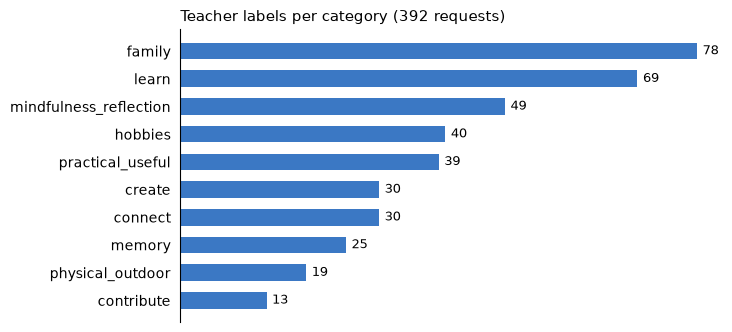

In [8]:
with open(TEACHER_DATA_JSONL, encoding="utf-8") as f:
    records = [json.loads(line) for line in f if line.strip()]
labels_df = pd.DataFrame(records)
display(labels_df.sample(5, random_state=1))

counts = labels_df["category"].value_counts().sort_values()
fig, ax = plt.subplots(figsize=(7, 3.8))
bars = ax.barh(counts.index, counts.values, color="#3b78c4", height=0.6)
ax.bar_label(bars, padding=4, fontsize=9)
ax.set_title(f"Teacher labels per category ({len(records)} requests)", loc="left", fontsize=11)
ax.spines[["top", "right", "bottom"]].set_visible(False)
ax.xaxis.set_visible(False)
ax.tick_params(left=False)
plt.show()

### 5.3 Training the student

Two small pipelines are trained on an 80/20 stratified split with a fixed seed: one predicts `category` (this drives retrieval) and one predicts `intent` (shown for explanation). TF-IDF on words and word pairs with Logistic Regression is fast and explainable, and suits a short-text task with about 400 examples.

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

RANDOM_STATE = 42
TEST_SIZE = 0.2

queries = [r["query"] for r in records]
category_labels = [r["category"] for r in records]
intent_labels = [r["intent"] for r in records]

idx_train, idx_test = train_test_split(
    range(len(records)), test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=category_labels
)
X_train = [queries[i] for i in idx_train]
X_test = [queries[i] for i in idx_test]


def build_pipeline() -> Pipeline:
    return Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=1)),
        ("clf", LogisticRegression(max_iter=1000)),
    ])


category_model = build_pipeline().fit(X_train, [category_labels[i] for i in idx_train])
intent_model = build_pipeline().fit(X_train, [intent_labels[i] for i in idx_train])


@dataclass
class StudentPrediction:
    category: str | None
    intent: str | None


@traceable(name="student_classifier", run_type="tool")
def predict(query: str) -> StudentPrediction:
    """The student: classify a request locally, with no network call."""
    return StudentPrediction(
        category=category_model.predict([query])[0],
        intent=intent_model.predict([query])[0],
    )


print(f"Trained on {len(idx_train)} requests, held out {len(idx_test)} for testing\n")
for q in ["Give me something I can do with my grandson for 30 minutes.",
          "I have one hour and want to do something useful at home.",
          "I feel tired today and don't want to go outside."]:
    p = predict(q)
    print(f"{q}\n  -> category={p.category}, intent={p.intent}")

Trained on 313 requests, held out 79 for testing

Give me something I can do with my grandson for 30 minutes.
  -> category=family, intent=family_activity
I have one hour and want to do something useful at home.
  -> category=practical_useful, intent=productive_activity
I feel tired today and don't want to go outside.
  -> category=mindfulness_reflection, intent=relax_and_reflect


### 5.4 How good is the student?

Scored on the held-out 20% that the student never saw during training. Rows of the matrix are the teacher's label, columns are what the student predicted; numbers off the diagonal are mistakes.

test examples   : 79
accuracy        : 0.924
macro precision : 0.933
macro recall    : 0.897
macro F1        : 0.904


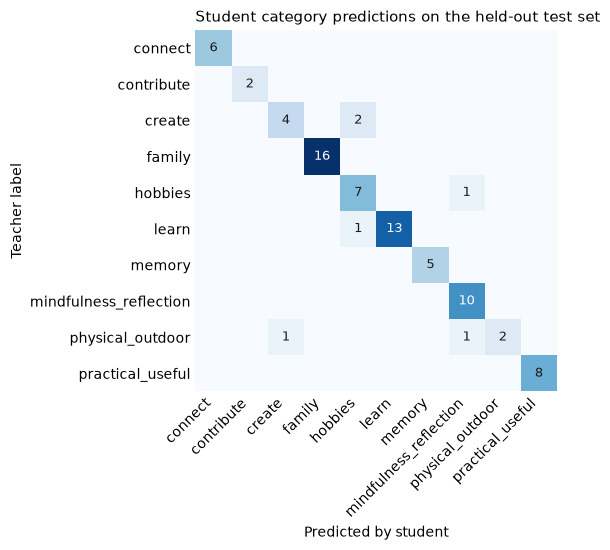

In [10]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_recall_fscore_support

y_true = [category_labels[i] for i in idx_test]
y_pred = list(category_model.predict(X_test))
matrix_labels = sorted(set(y_true) | set(y_pred))
precision, recall, f1, _ = precision_recall_fscore_support(
    y_true, y_pred, labels=matrix_labels, average="macro", zero_division=0
)
student_accuracy = accuracy_score(y_true, y_pred)

print(f"test examples   : {len(y_true)}")
print(f"accuracy        : {student_accuracy:.3f}")
print(f"macro precision : {precision:.3f}")
print(f"macro recall    : {recall:.3f}")
print(f"macro F1        : {f1:.3f}")

cm = confusion_matrix(y_true, y_pred, labels=matrix_labels)
fig, ax = plt.subplots(figsize=(6.8, 5.6))
ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(matrix_labels)), matrix_labels, rotation=45, ha="right")
ax.set_yticks(range(len(matrix_labels)), matrix_labels)
for i in range(len(matrix_labels)):
    for j in range(len(matrix_labels)):
        if cm[i, j]:
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=9,
                    color="white" if cm[i, j] > cm.max() / 2 else "#1a1a1a")
ax.set_xlabel("Predicted by student")
ax.set_ylabel("Teacher label")
ax.set_title("Student category predictions on the held-out test set", loc="left", fontsize=11)
ax.tick_params(length=0)
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()

### 5.5 Why bother? Speed

Both numbers below are **measured on this machine, right now**: the average of 5 student predictions against one real teacher API call. The teacher's time depends on the network.

In [11]:
sample_query = "I have 45 minutes and want to do something useful with my grandson."

predict(sample_query)  # warm up
start = time.perf_counter()
for _ in range(5):
    predict(sample_query)
student_ms = (time.perf_counter() - start) / 5 * 1000
print(f"student (average of 5 predictions): {student_ms:.2f} ms")

if HAS_KEY:
    try:
        teacher_llm = get_llm(temperature=0)
        start = time.perf_counter()
        label_query(sample_query, teacher_llm)
        teacher_ms = (time.perf_counter() - start) * 1000
        print(f"teacher (one Groq API call)       : {teacher_ms:.0f} ms")
        print(f"the student is about {teacher_ms / student_ms:.0f}x faster, and costs nothing per call")
    except Exception as e:
        print(f"Teacher call failed ({type(e).__name__}) - teacher latency not measured.")
else:
    print("teacher: not measured (no GROQ_API_KEY)")

student (average of 5 predictions): 4.40 ms


teacher (one Groq API call)       : 1912 ms
the student is about 434x faster, and costs nothing per call


## 6. Generation: a structured, grounded recommendation

The retrieved activities go into a prompt, and the LLM must **pick and personalise one of them**. Three things reduce hallucination:

1. **Prompt constraint:** the system prompt says the retrieved activities are the source of truth and nothing may be invented.
2. **Structured output:** the LLM must fill the `ActivityRecommendation` Pydantic schema. Pydantic validates the fields and types, so the rest of the program gets a proper object, never free text to parse.
3. **Grounding check:** afterwards, the recommended title is fuzzy-matched against the retrieved titles. Light personalisation passes; an invented activity is flagged.

In [12]:
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field, ValidationError


class ActivityRecommendation(BaseModel):
    title: str = Field(description="The activity's title, personalized for this user")
    reason: str = Field(description="One or two sentences on why this fits this person right now")
    duration_minutes: int = Field(description="Expected duration in minutes")
    category: str = Field(description="The activity's category")
    why_it_matches: list[str] = Field(description="2-4 short bullet points on why this matches the user")
    instructions: list[str] = Field(description="Concrete step-by-step instructions")
    materials: list[str] = Field(description="Materials needed, empty list if none")
    phone_free_message: str = Field(description="A short encouraging line to put the phone away and start")


SYSTEM_PROMPT = """You are SecondHalf, an assistant that recommends ONE offline activity to a \
retired adult so they can put their phone away and do something meaningful.

You are given a list of retrieved candidate activities (the RAG context) and the user's \
situation. You MUST select and personalize ONE activity from the retrieved candidates below. \
Use the retrieved activities as the source of truth - do not invent an activity, title, \
material, or instruction that isn't supported by the retrieved context. You may lightly \
personalize the wording (e.g. "teach a neighbour's child" instead of "teach a child") but the \
core activity must match one of the retrieved candidates.

Pick the single best match for the user's stated time, energy, mood, and interests. Write a \
short, warm, specific reason it fits THIS person. The phone_free_message should be a brief, \
encouraging line telling them to put their phone away and start."""

HUMAN_TEMPLATE = """User situation:
- Available time: {duration_minutes} minutes
- Energy level: {energy_level}
- Wants: {free_text}
- Recently done (avoid repeating): {avoid_titles}

Retrieved candidate activities (source of truth - pick one of these):
{retrieved_context}

Recommend ONE activity from the candidates above, personalized for this user."""

recommendation_prompt = ChatPromptTemplate.from_messages([("system", SYSTEM_PROMPT), ("human", HUMAN_TEMPLATE)])


def format_retrieved_context(scored_docs: list[tuple[Document, float]]) -> str:
    """Render the retrieved activities as numbered candidate blocks for the prompt."""
    blocks = []
    for i, (doc, score) in enumerate(scored_docs, 1):
        m = doc.metadata
        blocks.append(
            f"{i}. Title: {m['title']}\n"
            f"   Category: {m['category']} | Duration: {m['duration_minutes']} min | "
            f"Energy: {m['energy_level']} | Location: {m['location']}\n"
            f"   Materials: {m['required_materials']}\n"
            f"   Description: {doc.page_content}\n"
            f"   Similarity score: {score:.3f}"
        )
    return "\n\n".join(blocks)


class InvalidRecommendationError(Exception):
    """The LLM answered, but not with a valid ActivityRecommendation."""


def get_recommendation_llm():
    from groq import BadRequestError
    # with_structured_output makes the LLM answer through a tool call matching the schema.
    # Groq occasionally rejects a malformed tool call with HTTP 400; retry that once.
    return get_llm(temperature=0.3).with_structured_output(ActivityRecommendation).with_retry(
        retry_if_exception_type=(BadRequestError,), stop_after_attempt=2
    )


@traceable(name="recommendation_chain", run_type="chain")
def build_recommendation(retrieved, duration_minutes: int, energy_level: str, free_text: str,
                         avoid_titles: list[str], llm=None) -> ActivityRecommendation:
    """Retrieved documents -> prompt -> LLM -> validated ActivityRecommendation."""
    if not retrieved:
        raise ValueError("No retrieved activities to recommend from - retrieval returned empty.")
    llm = llm or get_recommendation_llm()
    messages = recommendation_prompt.format_messages(
        duration_minutes=duration_minutes,
        energy_level=energy_level,
        free_text=free_text or "(no specific request, open to suggestions)",
        avoid_titles=", ".join(avoid_titles) if avoid_titles else "none",
        retrieved_context=format_retrieved_context(retrieved),
    )
    try:
        result = llm.invoke(messages)
    except ValidationError as e:
        raise InvalidRecommendationError(f"LLM output failed schema validation: {e}") from e
    if not isinstance(result, ActivityRecommendation):
        raise InvalidRecommendationError("LLM returned no structured recommendation.")
    return result


@traceable(name="grounding_check", run_type="tool")
def check_grounding(recommendation: ActivityRecommendation, retrieved, threshold: float = 0.5) -> tuple[bool, str | None]:
    """Does the recommended title correspond to one of the retrieved activities?
    Fuzzy matching, because the LLM may lightly personalize the title.
    Returns (is_grounded, closest_retrieved_title)."""
    best_match, best_score = None, 0.0
    for doc, _ in retrieved:
        candidate = doc.metadata["title"]
        score = SequenceMatcher(None, recommendation.title.lower(), candidate.lower()).ratio()
        if score > best_score:
            best_match, best_score = candidate, score
    return best_score >= threshold, best_match

**The grounding check on its own (no LLM needed).** Two hand-written "LLM answers" are checked against a retrieved list: one is a light personalisation of a retrieved title, the other is an activity that was never retrieved.

In [13]:
def fake_recommendation(title: str) -> ActivityRecommendation:
    return ActivityRecommendation(title=title, reason="", duration_minutes=30, category="learn",
                                  why_it_matches=[], instructions=[], materials=[], phone_free_message="")


example_retrieved = [(doc, 0.5) for doc in documents[:5]]
print("Retrieved titles:", [doc.metadata["title"] for doc, _ in example_retrieved], "\n")

for title in [documents[1].metadata["title"] + " for your grandson", "Join a pottery class"]:
    grounded, closest = check_grounding(fake_recommendation(title), example_retrieved)
    print(f"{title!r}\n  -> {'grounded' if grounded else 'NOT grounded'} (closest retrieved: {closest!r})")

Retrieved titles: ['Learn ten words of a new language', 'Learn a magic trick', 'Identify local birds', 'Learn three constellations', 'Learn a Sanskrit shloka'] 

'Learn a magic trick for your grandson'
  -> grounded (closest retrieved: 'Learn a magic trick')
'Join a pottery class'
  -> NOT grounded (closest retrieved: 'Identify local birds')


## 7. Profile, history and feedback

The app remembers a small profile and what the user has done, in one local JSON file (single user, so no database).

The repetition rule lives here: anything done in the **last 3 days**, plus anything ever rated **"Didn't enjoy"**, is skipped by retrieval.

The demo user is **Mr. Sharma**, 67, who likes mathematics, teaching and gardening, and who **gardened yesterday**.

In [14]:
FEEDBACK_LABELS = {"loved": "😊 Loved it", "okay": "😐 It was okay", "disliked": "🙁 Didn't enjoy it"}
RECENT_DAYS = 3  # anything done in the last N days is not suggested again


@dataclass
class UserProfile:
    name: str = ""
    age: int = 65
    interests: list[str] = field(default_factory=list)
    preferred_categories: list[str] = field(default_factory=list)
    typical_energy: str = "medium"
    preferred_duration: int = 45
    social_preference: str = "medium"


@dataclass
class HistoryEntry:
    title: str
    category: str
    date: str                    # ISO date the user did it
    feedback: str | None = None  # a FEEDBACK_LABELS key; None until rated


def demo_profile() -> UserProfile:
    return UserProfile(
        name="Mr. Sharma", age=67,
        interests=["mathematics", "teaching", "gardening", "social interaction"],
        preferred_categories=["connect", "learn", "contribute"],
        typical_energy="medium", preferred_duration=45, social_preference="high",
    )


def demo_history() -> list[HistoryEntry]:
    today = date.today()
    return [
        HistoryEntry("Tend to the garden", "physical_outdoor", (today - timedelta(days=1)).isoformat(), "loved"),
        HistoryEntry("Take a brisk morning walk", "physical_outdoor", (today - timedelta(days=2)).isoformat(), "okay"),
        HistoryEntry("Organize a family photo album", "family", (today - timedelta(days=3)).isoformat(), "loved"),
    ]


def _read() -> dict:
    if not os.path.exists(USER_DATA_PATH):
        return {}
    with open(USER_DATA_PATH, encoding="utf-8") as f:
        return json.load(f)


def _write(data: dict) -> None:
    with open(USER_DATA_PATH, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=2, ensure_ascii=False)


def load_profile() -> UserProfile | None:
    raw = _read().get("profile")
    return UserProfile(**raw) if raw else None


def save_profile(profile: UserProfile) -> None:
    _write({**_read(), "profile": asdict(profile)})


def load_history() -> list[HistoryEntry]:
    """Newest first."""
    entries = [HistoryEntry(**e) for e in _read().get("history", [])]
    return sorted(entries, key=lambda e: e.date, reverse=True)


def save_history(entries: list[HistoryEntry]) -> None:
    _write({**_read(), "history": [asdict(e) for e in entries]})


def add_activity(title: str, category: str) -> None:
    """Record that the user committed to an activity ("I'll do this")."""
    save_history(load_history() + [HistoryEntry(title, category, date.today().isoformat())])


def set_feedback(title: str, feedback: str) -> None:
    """Attach feedback to the most recent unrated entry with this title."""
    if feedback not in FEEDBACK_LABELS:
        raise ValueError(f"Unknown feedback {feedback!r}")
    entries = load_history()
    for entry in entries:
        if entry.title == title and entry.feedback is None:
            entry.feedback = feedback
            break
    save_history(entries)


def load_demo() -> None:
    """Reset the stored profile and history to the Mr. Sharma demo state."""
    _write({"profile": asdict(demo_profile()), "history": [asdict(e) for e in demo_history()]})


def titles_to_avoid(history: list[HistoryEntry]) -> list[str]:
    """Skip anything done in the last RECENT_DAYS days, plus anything ever disliked."""
    cutoff = (date.today() - timedelta(days=RECENT_DAYS)).isoformat()
    avoid = [e.title for e in history if e.date >= cutoff or e.feedback == "disliked"]
    return list(dict.fromkeys(avoid))  # dedupe, keep order


def days_ago_label(iso_date: str) -> str:
    days = (date.today() - date.fromisoformat(iso_date)).days
    return {0: "Today", 1: "Yesterday"}.get(days, f"{days} days ago")


print("Demo profile:", demo_profile(), "\n")
display(pd.DataFrame([{"when": days_ago_label(e.date), "activity": e.title, "category": e.category,
                       "feedback": FEEDBACK_LABELS[e.feedback]} for e in demo_history()]))
print("Titles retrieval will skip today:", titles_to_avoid(demo_history()))

Demo profile: UserProfile(name='Mr. Sharma', age=67, interests=['mathematics', 'teaching', 'gardening', 'social interaction'], preferred_categories=['connect', 'learn', 'contribute'], typical_energy='medium', preferred_duration=45, social_preference='high') 



,when,activity,category,feedback
0,Yesterday,Tend to the garden,physical_outdoor,😊 Loved it
1,2 days ago,Take a brisk morning walk,physical_outdoor,😐 It was okay
2,3 days ago,Organize a family photo album,family,😊 Loved it


Titles retrieval will skip today: ['Tend to the garden', 'Take a brisk morning walk', 'Organize a family photo album']


## 8. The full pipeline

`get_recommendation` joins everything: **student → retrieval → LLM → validation → grounding check**. It returns every intermediate result as well as the final answer, so each step can be inspected.

In [15]:
@dataclass
class RecommendationResult:
    student_prediction: StudentPrediction
    category_used: str | None
    retrieval_query: str
    retrieved: list[tuple[Document, float]]
    recommendation: ActivityRecommendation
    is_grounded: bool
    grounded_match: str | None


@traceable(name="secondhalf_pipeline", run_type="chain")
def get_recommendation(free_text: str, duration_minutes: int, energy_level: str,
                       social_preference: str | None = None, interests: list[str] | None = None,
                       avoid_titles: list[str] | None = None,
                       category_override: str | None = None) -> RecommendationResult:
    """category_override is a category the user explicitly picked. It beats the student's
    guess, but the student still runs so its prediction stays visible."""
    avoid_titles = avoid_titles or []
    student_prediction = predict(free_text) if free_text.strip() else StudentPrediction(None, None)

    ctx = RetrievalContext(
        category=category_override or student_prediction.category,
        category_is_hard=category_override is not None,
        duration_minutes=duration_minutes,
        energy_level=energy_level,
        social_preference=social_preference,
        interests=interests or [],
        avoid_titles=avoid_titles,
        free_text=free_text,
    )
    query, retrieved = retrieve(ctx)
    if not retrieved:
        raise ValueError("No matching activities were found - try a different time or category.")

    recommendation = build_recommendation(retrieved, duration_minutes, energy_level, free_text, avoid_titles)
    is_grounded, matched = check_grounding(recommendation, retrieved)
    return RecommendationResult(student_prediction, ctx.category, query, retrieved, recommendation, is_grounded, matched)


# ---- rendering (used here and by the interactive app) ----

def esc(text) -> str:
    return html.escape(str(text))


MISSION_STYLE = "padding:12px 16px;border-radius:10px;background:rgba(46,125,50,.14);border-left:5px solid #2e7d32"


def recommendation_html(result: RecommendationResult) -> str:
    rec = result.recommendation
    warning = "" if result.is_grounded else (
        "<p><b>Note:</b> this suggestion didn't closely match our activity library, so treat it with care.</p>")
    return f"""
    <h3 style="margin-bottom:2px">{esc(rec.title)}</h3>
    <small>{esc(rec.category.replace('_', ' ').title())} · about {rec.duration_minutes} minutes</small>
    {warning}
    <h4>Why this activity?</h4>
    <p>{esc(rec.reason)}</p>
    <ul>{''.join(f'<li>{esc(p)}</li>' for p in rec.why_it_matches)}</ul>
    <h4>What to do</h4>
    <ol>{''.join(f'<li>{esc(s)}</li>' for s in rec.instructions)}</ol>
    <h4>You'll need</h4>
    <p>{esc(', '.join(rec.materials)) if rec.materials else 'Nothing special.'}</p>
    <h4>Phone-free mission</h4>
    <div style="{MISSION_STYLE}">{esc(rec.phone_free_message)}</div>
    """


def technical_html(result: RecommendationResult) -> str:
    """The six steps behind one recommendation: proof that RAG is really happening."""
    pred = result.student_prediction
    rows = "".join(
        f"<tr><td>{i}</td><td>{esc(doc.metadata['title'])}</td><td>{doc.metadata['category']}</td>"
        f"<td>{doc.metadata['duration_minutes']}</td><td>{score:.3f}</td></tr>"
        for i, (doc, score) in enumerate(result.retrieved, 1)
    )
    override = "" if result.category_used == pred.category else (
        f"<br><small>A category was picked explicitly, so retrieval used <b>{result.category_used}</b>.</small>")
    pre = "white-space:pre-wrap;font-size:12px;border:1px solid rgba(128,128,128,.4);border-radius:6px;padding:8px"
    return f"""
    <p><b>1. Student model prediction</b> (local classifier, no API call)<br>
       category = <code>{pred.category}</code>, intent = <code>{pred.intent}</code>{override}</p>
    <p><b>2. Retrieval query</b> (sent to Chroma)<br><code>{esc(result.retrieval_query)}</code></p>
    <p><b>3. Top-k retrieved activities</b> (cosine similarity)</p>
    <table><tr><th>#</th><th>activity</th><th>category</th><th>minutes</th><th>similarity</th></tr>{rows}</table>
    <p><b>4. Context given to the LLM</b></p>
    <pre style="{pre}">{esc(format_retrieved_context(result.retrieved))}</pre>
    <p><b>5. LLM output</b> (validated against the Pydantic schema)</p>
    <pre style="{pre}">{esc(json.dumps(result.recommendation.model_dump(), indent=2, ensure_ascii=False))}</pre>
    <p><b>6. Grounding check</b><br>
       {'grounded' if result.is_grounded else 'NOT grounded'}: closest retrieved activity is
       <i>{esc(result.grounded_match)}</i></p>
    """

**Demo: Mr. Sharma asks for "something useful and preferably with another person".**

He gardened yesterday, so gardening is on the avoid list and should not be suggested, even though it is one of his interests. The technical details underneath show each step of the pipeline for this one request.

In [16]:
DEMO_REQUEST = "I want to do something useful and preferably with another person."
sharma = demo_profile()
sharma_avoid = titles_to_avoid(demo_history())
print("Avoiding:", sharma_avoid)

if HAS_KEY:
    try:
        demo_result = get_recommendation(
            free_text=DEMO_REQUEST, duration_minutes=sharma.preferred_duration, energy_level=sharma.typical_energy,
            social_preference=sharma.social_preference, interests=sharma.interests, avoid_titles=sharma_avoid,
        )
        display(HTML(recommendation_html(demo_result)))
        display(HTML("<hr><h4>Technical details (how this was chosen)</h4>" + technical_html(demo_result)))
    except Exception as e:
        print(f"Recommendation failed ({type(e).__name__}) - skipped.")
else:
    print(NO_KEY_MESSAGE, "\nShowing the steps that run without a key instead:\n")
    pred = predict(DEMO_REQUEST)
    print(f"Student prediction: category={pred.category}, intent={pred.intent}")
    query, hits = retrieve(RetrievalContext(
        category=pred.category, category_is_hard=False, duration_minutes=sharma.preferred_duration,
        social_preference=sharma.social_preference, interests=sharma.interests,
        avoid_titles=sharma_avoid, free_text=DEMO_REQUEST))
    print("Retrieval query:", query)
    display(hits_table(hits))

Avoiding: ['Tend to the garden', 'Take a brisk morning walk', 'Organize a family photo album']


#,activity,category,minutes,similarity
1,Offer free computer or smartphone help to elders,contribute,30,0.558
2,Try a jigsaw puzzle,hobbies,45,0.533
3,Start a small book discussion circle,connect,60,0.482
4,Practice a craft you learned as a child,hobbies,30,0.478
5,Tutor an underprivileged child for free,contribute,45,0.474


## 9. Evaluation questions

The 8 evaluation questions in `data/evaluation_questions.json` are run through the pipeline as Mr. Sharma (45 minutes, medium energy, gardening done yesterday). For each one the table shows what the student predicted, the best retrieved activity and its similarity and, when a Groq key is present, what the LLM recommended and whether it passed the grounding check.

Reading the `grounded` column: the check compares **titles only**. `False` means the LLM's title was not close enough to any retrieved title. That catches invented activities, but it also flags a real retrieved activity whose title the LLM reworded heavily; compare `recommended` with `closest retrieved` to tell which. The LLM runs at temperature 0.3, so the wording and the count vary a little between runs.

In [17]:
with open(EVALUATION_QUESTIONS_JSON, encoding="utf-8") as f:
    evaluation_questions = json.load(f)

rows = []
for question in evaluation_questions:
    pred = predict(question)
    _, hits = retrieve(RetrievalContext(
        category=pred.category, category_is_hard=False, duration_minutes=sharma.preferred_duration,
        social_preference=sharma.social_preference, interests=sharma.interests,
        avoid_titles=sharma_avoid, free_text=question))
    row = {"question": question, "student category": pred.category,
           "top retrieved": hits[0][0].metadata["title"], "similarity": round(hits[0][1], 3)}
    if HAS_KEY:
        try:
            rec = build_recommendation(hits, sharma.preferred_duration, sharma.typical_energy, question, sharma_avoid)
            row["recommended"] = rec.title
            row["grounded"], row["closest retrieved"] = check_grounding(rec, hits)
        except Exception as e:
            row["recommended"] = f"(failed: {type(e).__name__})"
            row["grounded"], row["closest retrieved"] = None, None
    rows.append(row)

evaluation_df = pd.DataFrame(rows)
if HAS_KEY:
    print(f"Grounded: {int(evaluation_df['grounded'].fillna(False).sum())} of {len(evaluation_df)}")
else:
    print(NO_KEY_MESSAGE, "Retrieval columns only.")
evaluation_df

Grounded: 7 of 8


,question,student category,top retrieved,similarity,recommended,grounded,closest retrieved
0,I have 30 minutes and want to do something useful at home.,practical_useful,Try a jigsaw puzzle,0.590,Organize a Home Tool Kit for Easy Access,True,Organize a home tool kit
1,I want something I can do with my grandson.,family,Teach grandchildren a card or board game from your youth,0.551,Teach Your Grandson a Traditional Skill,True,Teach a grandchild a traditional skill
2,I feel tired today and don't want to go outside.,mindfulness_reflection,Visit a local park bench and people-watch,0.574,Complete a 45‑Minute Jigsaw Puzzle,True,Try a jigsaw puzzle
3,I want to learn something new.,learn,Offer free computer or smartphone help to elders,0.551,Tutor an underprivileged child for free,True,Tutor an underprivileged child for free
4,I enjoy gardening but I did it yesterday.,hobbies,Try a jigsaw puzzle,0.536,Try a Watercolor Painting of a Garden Scene,True,Try your hand at watercolour painting
5,I want something social.,connect,Try a jigsaw puzzle,0.525,Join a Friendly Neighborhood Walking Group,True,Join a local walking group
6,I have one hour and want to create something.,create,Try a jigsaw puzzle,0.572,Create a Small Clay Pot or Figurine,False,Try pottery or clay modelling
7,I want to help someone.,mindfulness_reflection,Offer free computer or smartphone help to elders,0.592,Tutor an underprivileged child for free,True,Tutor an underprivileged child for free


## 10. Sanity checks

Automated checks of the behaviour described above. None of them needs an API key. If any check fails, the cell stops with an error.

In [18]:
import tempfile

# Dataset
assert len(activities) == 200 and {a["category"] for a in activities} == set(CATEGORIES)
assert all(isinstance(a["instructions"], list) and a["instructions"] for a in activities)

# Query and filter
ctx = RetrievalContext(category="learn", duration_minutes=45, interests=["teaching"], free_text="something calm")
assert "45" not in build_query(ctx) and "teaching" in build_query(ctx)       # duration is a filter, not query text
clauses = build_metadata_filter(ctx)["$and"]
assert {"duration_minutes": {"$gte": 25}} in clauses and {"duration_minutes": {"$lte": 65}} in clauses

# Retrieval
_, hits = retrieve(RetrievalContext(category="learn", category_is_hard=True, duration_minutes=45))
assert len(hits) == RETRIEVAL_K and all(doc.metadata["category"] == "learn" for doc, _ in hits)
assert all(-1.0 <= score <= 1.0 for _, score in hits)
assert [s for _, s in hits] == sorted((s for _, s in hits), reverse=True)    # best first

_, soft = retrieve(RetrievalContext(category="practical_useful", category_is_hard=False, **person))
assert any(doc.metadata["category"] != "practical_useful" for doc, _ in soft)  # soft category is not a filter

first_title = hits[0][0].metadata["title"]
_, without = retrieve(RetrievalContext(category="learn", duration_minutes=45, avoid_titles=[first_title]))
assert first_title not in [doc.metadata["title"] for doc, _ in without]      # avoided titles never come back

# Student
assert predict("Give me something I can do with my grandson for 30 minutes.").category == "family"
assert predict("anything at all").category in CATEGORIES
assert student_accuracy > 0.85

# Grounding
assert check_grounding(fake_recommendation(documents[1].metadata["title"] + " for your grandson"), example_retrieved)[0]
assert not check_grounding(fake_recommendation("Join a pottery class"), example_retrieved)[0]

# Empty retrieval is rejected before any LLM call
try:
    build_recommendation([], 30, "low", "", [])
    raise AssertionError("expected ValueError")
except ValueError:
    pass

# Profile, history and feedback (on a temporary file, so the real one is untouched)
_real_path = USER_DATA_PATH
USER_DATA_PATH = os.path.join(tempfile.mkdtemp(), "user_data.json")
try:
    assert load_profile() is None
    load_demo()
    assert load_profile().name == "Mr. Sharma"
    assert "Tend to the garden" in titles_to_avoid(load_history())           # gardened yesterday
    add_activity("Learn a magic trick", "learn")
    set_feedback("Learn a magic trick", "disliked")
    assert load_history()[0].feedback == "disliked"
    old = HistoryEntry("Old disliked thing", "learn", "2020-01-01", "disliked")
    assert "Old disliked thing" in titles_to_avoid([old])                    # disliked is avoided forever
    assert titles_to_avoid([HistoryEntry("Old loved thing", "learn", "2020-01-01", "loved")]) == []
finally:
    USER_DATA_PATH = _real_path

print("All sanity checks passed.")

All sanity checks passed.


## 11. Interactive app

The whole product as a small app inside the notebook. The flow is short and one-way on purpose, because the goal is to get the user **off** the screen:

**Profile → Today's request → ONE recommendation → "I'll do this" → Phone away → Feedback**

**Run the cell below to start the app**, then:

1. Click **Load demo profile (Mr. Sharma)**. The request box is filled in for you.
2. Leave **Surprise me** selected and click **Find my activity**. (Needs the Groq key; takes a couple of seconds.)
3. Open **Technical details** to see the student prediction, the retrieval query, the top-5 activities, the context sent to the LLM, the validated output and the grounding result.
4. Click **I'll do this → I'm back →** a feedback button. The history panel on the right updates, and that activity is now skipped for the next 3 days.
5. Pick a specific type such as **Outside** to see the category applied as a hard filter.

Profile and history are saved in `data/user_data_notebook.json`. Delete that file to start again from an empty profile.

In [19]:
import ipywidgets as W

# Button label -> dataset category. "Surprise me" leaves it to the student model.
CATEGORY_CHOICES = {"Surprise me": None, "Learn": "learn", "Create": "create", "Connect": "connect",
                    "Contribute": "contribute", "Useful": "practical_useful", "Outside": "physical_outdoor"}
LEVELS = ["low", "medium", "high"]
FLOW_STEPS = [("today", "Choose"), ("recommendation", "Recommendation"), ("offline", "Phone away"), ("feedback", "Feedback")]


def friendly_error(e: Exception) -> str:
    """Map pipeline failures to messages a user can act on. Never shows provider error text."""
    name = type(e).__name__
    if isinstance(e, RuntimeError) and "GROQ_API_KEY" in str(e):
        return "No Groq API key found. Add GROQ_API_KEY to the .env file and re-run the notebook."
    if isinstance(e, InvalidRecommendationError) or "BadRequest" in name:
        return "The AI gave an answer we couldn't read. Please try again."
    if isinstance(e, ValueError) and "No matching activities" in str(e):
        return str(e)
    if "Timeout" in name:
        return "The recommendation service took too long to respond. Please try again in a moment."
    if "Authentication" in name or "PermissionDenied" in name:
        return "The Groq API key was rejected. Check GROQ_API_KEY in the .env file."
    if "Connection" in name:
        return "Couldn't reach the recommendation service. Check your internet connection."
    if "RateLimit" in name:
        return "Too many requests to the AI service right now. Wait a minute and try again."
    return f"Something went wrong ({name}). Please try again."


class SecondHalfApp:
    def __init__(self):
        self.result = None
        self.committed_title = ""
        self.buttons = {}
        self.free_text = W.Textarea(
            placeholder="e.g. something calm at home, or something with my grandson",
            layout=W.Layout(width="100%", height="70px"))
        self.main = W.VBox(layout=W.Layout(flex="3", padding="0 20px 0 0"))
        self.side = W.VBox(layout=W.Layout(flex="2", padding="0 0 0 16px", border_left="1px solid rgba(128,128,128,.4)"))
        self.root = W.VBox([
            W.HTML("<h2 style='margin-bottom:0'>SecondHalf</h2><i>Spend less time scrolling. Spend more time living.</i>"),
            W.HBox([self.main, self.side]),
        ])
        self.show("today" if load_profile() else "profile")

    # ---- helpers ----
    def button(self, label: str, handler, style: str = "") -> W.Button:
        b = W.Button(description=label, button_style=style, layout=W.Layout(width="auto"))
        b.on_click(lambda _: handler())
        self.buttons[label] = b
        return b

    def show(self, step: str) -> None:
        self.step = step
        self.main.children = getattr(self, f"screen_{step}")()
        self.side.children = self.sidebar()

    def flow_bar(self) -> W.HTML:
        return W.HTML(" → ".join(f"<b>[{label}]</b>" if key == self.step else label for key, label in FLOW_STEPS))

    # ---- side panel: demo, profile summary, history ----
    def sidebar(self) -> list:
        items = [self.button("Load demo profile (Mr. Sharma)", self.load_demo)]
        profile = load_profile()
        if profile:
            items.append(W.HTML(
                f"<h4 style='margin-bottom:0'>{esc(profile.name)}, {profile.age}</h4>"
                f"<small>Interests: {esc(', '.join(profile.interests) or '-')}<br>"
                f"Usually: {profile.typical_energy} energy · {profile.preferred_duration} min · "
                f"{profile.social_preference} social</small>"))
            items.append(self.button("Edit profile", lambda: self.show("profile")))
        history = load_history()
        if history:
            lines = "".join(
                f"<p style='margin:4px 0'><b>{days_ago_label(e.date)}</b><br>{esc(e.title)}: "
                f"{FEEDBACK_LABELS.get(e.feedback, 'not rated yet')}</p>" for e in history[:5])
            avoid = titles_to_avoid(history)
            skipped = f"<small>Skipped today to avoid repetition: {esc('; '.join(avoid))}</small>" if avoid else ""
            items.append(W.HTML(f"<h4 style='margin-bottom:0'>Recent activities</h4>{lines}{skipped}"))
        return items

    def load_demo(self) -> None:
        load_demo()
        self.free_text.value = DEMO_REQUEST
        self.result = None
        self.show("today")

    # ---- screen 1: profile ----
    def screen_profile(self) -> list:
        current = load_profile() or UserProfile()
        options = sorted({i for a in activities for i in a["interests"]} | set(current.interests))
        wide = {"description_width": "110px"}
        name = W.Text(value=current.name, description="Name", style=wide)
        age = W.BoundedIntText(value=current.age, min=40, max=110, description="Age", style=wide)
        interests = W.SelectMultiple(options=options, value=tuple(current.interests), rows=7, description="Interests", style=wide)
        preferred = W.SelectMultiple(options=CATEGORIES, value=tuple(current.preferred_categories), rows=5,
                                     description="Preferred types", style=wide)
        energy = W.SelectionSlider(options=LEVELS, value=current.typical_energy, description="Typical energy", style=wide)
        duration = W.IntSlider(value=current.preferred_duration, min=10, max=120, step=5, description="Usual minutes", style=wide)
        social = W.SelectionSlider(options=LEVELS, value=current.social_preference, description="Enjoys company", style=wide)
        message = W.HTML()

        def save():
            if not name.value.strip():
                message.value = "<b>Please enter a name.</b>"
                return
            save_profile(UserProfile(
                name=name.value.strip(), age=age.value, interests=list(interests.value),
                preferred_categories=list(preferred.value), typical_energy=energy.value,
                preferred_duration=duration.value, social_preference=social.value))
            self.show("today")

        return [W.HTML("<h3>Tell us a little about yourself</h3>"
                       "<small>Hold Ctrl (Cmd on Mac) and click to choose several interests.</small>"),
                name, age, interests, preferred, energy, duration, social,
                self.button("Save profile", save, "success"), message]

    # ---- screen 2: today's request ----
    def screen_today(self) -> list:
        profile = load_profile()
        wide = {"description_width": "110px"}
        self.choice = W.ToggleButtons(options=list(CATEGORY_CHOICES), style={"button_width": "auto"})
        self.duration = W.IntSlider(value=profile.preferred_duration, min=10, max=120, step=5,
                                    description="Minutes free", style=wide)
        self.energy = W.SelectionSlider(options=LEVELS, value=profile.typical_energy, description="Energy level", style=wide)
        self.error = W.HTML()
        return [self.flow_bar(),
                W.HTML(f"<h3>Namaste, {esc(profile.name)}. What would you like to do today?</h3>"),
                self.choice, self.duration, self.energy,
                W.HTML("Tell us what you're in the mood for (optional)"), self.free_text,
                self.button("Find my activity", self.find, "success"), self.error]

    def find(self) -> None:
        profile = load_profile()
        self.error.value = "<i>Finding something good for you…</i>"
        try:
            self.result = get_recommendation(
                free_text=self.free_text.value,
                duration_minutes=self.duration.value,
                energy_level=self.energy.value,
                social_preference=profile.social_preference,
                interests=profile.interests,
                avoid_titles=titles_to_avoid(load_history()),
                category_override=CATEGORY_CHOICES[self.choice.value],
            )
        except Exception as e:  # every failure gets a friendly message
            self.error.value = f"<b>{esc(friendly_error(e))}</b>"
            return
        self.show("recommendation")

    # ---- screen 3: recommendation ----
    def screen_recommendation(self) -> list:
        details = W.Accordion(children=[W.HTML(technical_html(self.result))],
                              titles=("Technical details (how this was chosen)",), selected_index=None)
        return [self.flow_bar(), W.HTML(recommendation_html(self.result)),
                W.HBox([self.button("I'll do this", self.commit, "success"),
                        self.button("Change my request", lambda: self.show("today"))]),
                details]

    def commit(self) -> None:
        rec = self.result.recommendation
        # Store the dataset's own title when grounded, so the avoid list matches retrieval exactly.
        self.committed_title = self.result.grounded_match if self.result.is_grounded else rec.title
        add_activity(self.committed_title, self.result.category_used or rec.category)
        self.show("offline")

    # ---- screens 4-6: phone away, feedback, done ----
    def screen_offline(self) -> list:
        rec = self.result.recommendation
        return [self.flow_bar(),
                W.HTML(f"<h3>Time to put the phone down</h3>"
                       f"<div style='{MISSION_STYLE}'>{esc(rec.phone_free_message)}</div>"
                       f"<p>Enjoy <b>{esc(rec.title)}</b>. This page will wait here. Come back only when you're done.</p>"),
                self.button("I'm back", lambda: self.show("feedback"), "success")]

    def screen_feedback(self) -> list:
        def rate(key):
            return lambda: (set_feedback(self.committed_title, key), self.show("done"))
        return [self.flow_bar(),
                W.HTML(f"<h3>How was it?</h3><small>{esc(self.committed_title)}</small>"),
                W.HBox([self.button(label, rate(key)) for key, label in FEEDBACK_LABELS.items()])]

    def screen_done(self) -> list:
        def again():
            self.result = None
            self.show("today")
        return [W.HTML("<h3>Thank you!</h3><p>Your feedback helps us suggest better activities next time. "
                       "That's all for now. Enjoy the rest of your day away from the screen.</p>"),
                self.button("Plan another activity", again)]


app = SecondHalfApp()
display(app.root)

## 12. LangSmith tracing (optional)

An LLM pipeline has several hidden steps. When an answer looks wrong, tracing shows *which* step failed: did the student misclassify, did retrieval find poor candidates, or did the LLM ignore good ones?

The functions above are decorated with `@traceable`, so each request is recorded as one tree:

```
secondhalf_pipeline
├── student_classifier     (predicted category / intent)
├── rag_retrieval          (query + retrieved documents)
├── recommendation_chain   (ChatGroq -> structured output)
└── grounding_check
```

To turn it on, add these to `.env` and restart the kernel (free account at https://smith.langchain.com):

```
LANGCHAIN_API_KEY=<your key>
LANGCHAIN_TRACING_V2=true
LANGCHAIN_PROJECT=secondhalf
```

With tracing off, the decorators do nothing and the notebook behaves the same.

## 13. Limitations

- **Imbalanced teacher data:** very few of the labelled requests are `contribute` (see the chart in 5.2), so the student is weak on requests like "I want to help someone". In *Surprise me* mode the category is only a boost, which limits the damage; more `contribute` examples are the real fix.
- **Hard-label distillation only:** the student learns the teacher's answers, not its probabilities (see section 5).
- **Template-style training requests:** the student has mostly seen template-like phrasing, so very unusual wording may be classified less accurately than the test score suggests.
- **Fuzzy title grounding:** the check compares *titles*. Invented steps under a valid title would not be caught, and heavy rewording of a valid title could be flagged falsely.
- **Energy level** is passed to the LLM but is not used as a retrieval filter.
- **Single user, local JSON storage:** no accounts, no multi-device sync.
- Needs internet for the Groq call, and once for the embedding model download.

## 14. Possible improvements

- More teacher data for the weak categories, then re-evaluate.
- Soft-label distillation using a model that exposes class probabilities.
- A larger RAG evaluation (retrieval relevance@k and grounding rate over many questions).
- Use energy level and indoor/outdoor preference as retrieval filters.
- Hindi and regional-language interface, and voice input for users who find typing difficult.